# Ejercicio 5: Espacio Vectorial

## Objetivo de la práctica
- Implementar un Sistema de Recuperación de Información completo, desde la lectura del corpus hasta la recuperación de resultados.

## Parte 0: Carga del Corpus

Vamos a utilizar la API de Kaggle para acceder al dataset _Wikipedia Text Corpus for NLP and LLM Projects_

El corpus está disponible desde este [link](https://www.kaggle.com/datasets/gzdekzlkaya/wikipedia-text-corpus-for-nlp-and-llm-projects?utm_source=chatgpt.com)

### Actividad

1. Carga el corpus
2. Realiza las etapas de preprocesamiento sobre el corpus


In [4]:
import pandas as pd

# Cargar el corpus desde el archivo CSV
corpus_df = pd.read_csv('archive/wikipedia_text_corpus.csv')

# Mostrar las primeras filas para verificar
corpus_df.head()

,Unnamed: 0,text
0,1,Anovo\n\nAnovo (formerly A Novo) is a computer...
1,2,Battery indicator\n\nA battery indicator (also...
2,3,"Bob Pease\n\nRobert Allen Pease (August 22, 19..."
3,4,CAVNET\n\nCAVNET was a secure military forum w...
4,5,CLidar\n\nThe CLidar is a scientific instrumen...


In [13]:

##limpiar los datos
import re

# Función para limpiar el texto
def clean_text(text):
    # Convertir a minúsculas
    text = text.lower()
    # Remover símbolos especiales y puntuación (mantener letras, números y espacios)
    text = re.sub(r'[^\w\s]', '', text)
    # Remover espacios extra
    text = re.sub(r'\s+', ' ', text)
    # Remover espacios al inicio y final
    return text.strip()

# Aplicar la limpieza al corpus
corpus_df['cleaned_text'] = corpus_df['text'].apply(clean_text)

# Mostrar un ejemplo de texto limpio
print("Texto original:")
print(corpus_df['text'].iloc[0][:200])
print("\nTexto limpio:")
print(corpus_df['cleaned_text'].iloc[0][:200])

Texto original:
Anovo

Anovo (formerly A Novo) is a computer services company based in Beauvais, France. It was founded in 1987, went public in 1999, and is currently a member of the CAC Small.

It won in the categor

Texto limpio:
anovo anovo formerly a novo is a computer services company based in beauvais france it was founded in 1987 went public in 1999 and is currently a member of the cac small it won in the category service


In [6]:
#tokenizacion
import nltk
from nltk.tokenize import word_tokenize

# Descargar el tokenizador si no está disponible
nltk.download('punkt_tab')

# Tokenizar el texto limpio
corpus_df['tokens'] = corpus_df['cleaned_text'].apply(word_tokenize)

# Mostrar un ejemplo de tokens
print("Texto limpio:")
print(corpus_df['cleaned_text'].iloc[0][:100])
print("\nTokens:")
print(corpus_df['tokens'].iloc[0][:20])

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\LabP5E004\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Texto limpio:
anovo anovo formerly a novo is a computer services company based in beauvais france it was founded i

Tokens:
['anovo', 'anovo', 'formerly', 'a', 'novo', 'is', 'a', 'computer', 'services', 'company', 'based', 'in', 'beauvais', 'france', 'it', 'was', 'founded', 'in', '1987', 'went']


In [7]:
#realizar stemming
from nltk.stem import PorterStemmer

# Inicializar el stemmer
stemmer = PorterStemmer()

# Aplicar stemming a los tokens
corpus_df['stemmed_tokens'] = corpus_df['tokens'].apply(lambda tokens: [stemmer.stem(word) for word in tokens])

# Mostrar un ejemplo
print("Tokens originales:")
print(corpus_df['tokens'].iloc[0][:15])
print("\nTokens stemmed:")
print(corpus_df['stemmed_tokens'].iloc[0][:15])

Tokens originales:
['anovo', 'anovo', 'formerly', 'a', 'novo', 'is', 'a', 'computer', 'services', 'company', 'based', 'in', 'beauvais', 'france', 'it']

Tokens stemmed:
['anovo', 'anovo', 'formerli', 'a', 'novo', 'is', 'a', 'comput', 'servic', 'compani', 'base', 'in', 'beauvai', 'franc', 'it']


In [8]:
# Unir los tokens stemmed en una cadena de texto
corpus_df['processed_text'] = corpus_df['stemmed_tokens'].apply(lambda tokens: ' '.join(tokens))

# Mostrar un ejemplo del texto procesado
print("Texto procesado (stemmed y unido):")
print(corpus_df['processed_text'].iloc[0][:150])

Texto procesado (stemmed y unido):
anovo anovo formerli a novo is a comput servic compani base in beauvai franc it wa found in 1987 went public in 1999 and is current a member of the ca


## Parte 1: Recuperación con TF-IDF

### Actividad:
3. Obtén la representación vectorial de los documentos utilizando el modelo TF-IDF
4. A partir de un conjunto de 10 queries, verifica la recuperación del sistema

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Crear el vectorizador TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=1000, stop_words='english')

# Ajustar el vectorizador y transformar el corpus
tfidf_matrix = tfidf_vectorizer.fit_transform(corpus_df['processed_text'])

print(f"Matriz TF-IDF shape: {tfidf_matrix.shape}")
print(f"Documentos: {tfidf_matrix.shape[0]}, Características (términos): {tfidf_matrix.shape[1]}")

Matriz TF-IDF shape: (10859, 1000)
Documentos: 10859, Características (términos): 1000


In [10]:
# Crear 10 queries de prueba
queries = [
    "artificial intelligence machine learning",
    "computer science algorithms",
    "python programming language",
    "data science statistics",
    "neural networks deep learning",
    "web development internet",
    "database management systems",
    "cloud computing distributed systems",
    "natural language processing",
    "computer graphics visualization"
]

# Procesar las queries de la misma manera que el corpus
processed_queries = []
for query in queries:
    # Limpiar
    cleaned = clean_text(query)
    # Tokenizar
    tokens = word_tokenize(cleaned)
    # Stemming
    stemmed = [stemmer.stem(word) for word in tokens]
    # Join
    processed_queries.append(' '.join(stemmed))

# Transformar las queries usando el vectorizador TF-IDF
queries_tfidf = tfidf_vectorizer.transform(processed_queries)

# Calcular similitud coseno entre queries y documentos
similarities = cosine_similarity(queries_tfidf, tfidf_matrix)

print(f"Matriz de similitud shape: {similarities.shape}\n")

# Mostrar los 5 documentos más relevantes para cada query
for i, query in enumerate(queries):
    print(f"\nQuery {i+1}: '{query}'")
    # Obtener los índices de los documentos ordenados por similitud
    top_indices = np.argsort(similarities[i])[::-1][:5]
    print("Top 5 documentos recuperados:")
    for rank, idx in enumerate(top_indices, 1):
        similarity_score = similarities[i][idx]
        doc_title = corpus_df['text'].iloc[idx][:60].replace('\n', ' ')
        print(f"  {rank}. [Doc {idx}] Similitud: {similarity_score:.4f} - {doc_title}...")

Matriz de similitud shape: (10, 10859)


Query 1: 'artificial intelligence machine learning'
Top 5 documentos recuperados:
  1. [Doc 10547] Similitud: 0.7592 - Outline of machine learning  The following outline is provid...
  2. [Doc 4733] Similitud: 0.5932 - Teaching machine  Teaching machines were originally mechanic...
  3. [Doc 9538] Similitud: 0.5210 - DoceboLMS  Docebo is a software as a service artificial inte...
  4. [Doc 3905] Similitud: 0.4879 - Accounting intelligence  A specialist form of business intel...
  5. [Doc 7900] Similitud: 0.4833 - Digital learning  Digital learning is any type of learning t...

Query 2: 'computer science algorithms'
Top 5 documentos recuperados:
  1. [Doc 9852] Similitud: 0.8481 - Philosophy of computer science  The philosophy of computer s...
  2. [Doc 9489] Similitud: 0.8100 - Computer science  Computer science is the theory, experiment...
  3. [Doc 9402] Similitud: 0.6179 - Ministry of Science (Serbia)  The Ministry of Science of the...
  4. [

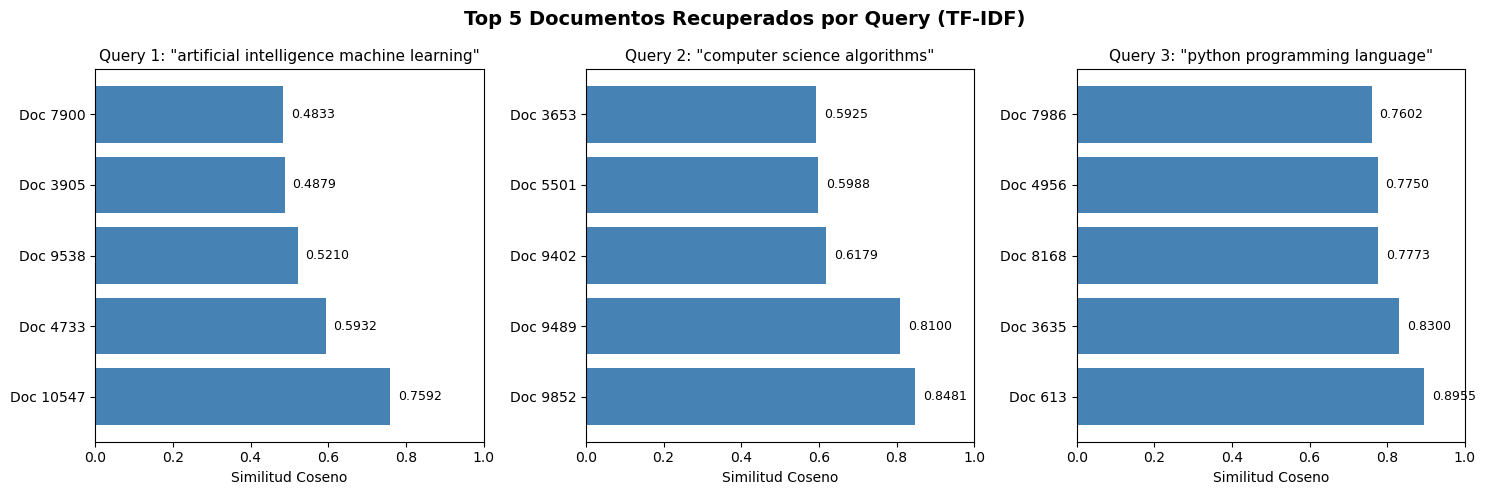


RESUMEN DE RECUPERACIÓN - TF-IDF
Total documentos en corpus: 10859
Total queries: 10
Características (términos) TF-IDF: 1000



In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear figura con subplots para los primeros 3 queries
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Top 5 Documentos Recuperados por Query (TF-IDF)', fontsize=14, fontweight='bold')

for i in range(3):
    ax = axes[i]
    
    # Obtener los indices de los documentos ordenados por similitud
    top_indices = np.argsort(similarities[i])[::-1][:5]
    top_scores = similarities[i][top_indices]
    
    # Crear labels con números de documento
    doc_labels = [f'Doc {idx}' for idx in top_indices]
    
    # Crear gráfico de barras
    bars = ax.barh(doc_labels, top_scores, color='steelblue')
    ax.set_xlabel('Similitud Coseno')
    ax.set_title(f'Query {i+1}: "{queries[i]}"', fontsize=11)
    ax.set_xlim(0, 1)
    
    # Añadir valores en las barras
    for j, (bar, score) in enumerate(zip(bars, top_scores)):
        ax.text(score + 0.02, j, f'{score:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()



# Tabla resumen
print("\n" + "="*80)
print("RESUMEN DE RECUPERACIÓN - TF-IDF")
print("="*80)
print(f"Total documentos en corpus: {len(corpus_df)}")
print(f"Total queries: {len(queries)}")
print(f"Características (términos) TF-IDF: {tfidf_matrix.shape[1]}\n")



## Parte 2: Recuperación con BM25

### Actividad:
5. Implementa un sistema de recuperación usando el modelo BM25.
6. Para el mismo conjunto de 10 queries, verifica la recuperación del sistema

In [12]:
%pip install "rank-bm25" -q

from rank_bm25 import BM25Okapi

# Crear índice BM25 usando los tokens stemmed
corpus_tokens = corpus_df['stemmed_tokens'].tolist()
bm25 = BM25Okapi(corpus_tokens)

# Procesar las mismas queries para BM25
bm25_scores_all = []

print("="*80)
print("RECUPERACIÓN CON BM25")
print("="*80 + "\n")

for i, query in enumerate(queries):
    # Procesar la query igual que el corpus
    cleaned = clean_text(query)
    tokens = word_tokenize(cleaned)
    stemmed = [stemmer.stem(word) for word in tokens]
    
    # Calcular scores BM25
    scores = bm25.get_scores(stemmed)
    bm25_scores_all.append(scores)
    
    # Obtener top 5 documentos
    top_indices = np.argsort(scores)[::-1][:5]
    
    print(f"Query {i+1}: '{query}'")
    print("Top 5 documentos recuperados:")
    for rank, idx in enumerate(top_indices, 1):
        bm25_score = scores[idx]
        doc_title = corpus_df['text'].iloc[idx][:60].replace('\n', ' ')
        print(f"  {rank}. [Doc {idx}] BM25 Score: {bm25_score:.4f} - {doc_title}...")
    print()

bm25_scores_all = np.array(bm25_scores_all)

Note: you may need to restart the kernel to use updated packages.
RECUPERACIÓN CON BM25

Query 1: 'artificial intelligence machine learning'
Top 5 documentos recuperados:
  1. [Doc 10547] BM25 Score: 21.6421 - Outline of machine learning  The following outline is provid...
  2. [Doc 8528] BM25 Score: 19.5939 - Trace3  Trace3, Inc. is an Irvine, CA-based Information tech...
  3. [Doc 5991] BM25 Score: 19.0864 - Insilico Medicine  Insilico Medicine is an American biotechn...
  4. [Doc 9538] BM25 Score: 18.8847 - DoceboLMS  Docebo is a software as a service artificial inte...
  5. [Doc 6569] BM25 Score: 18.6434 - Cybernetics and Systems  Cybernetics and Systems is a peer-r...

Query 2: 'computer science algorithms'
Top 5 documentos recuperados:
  1. [Doc 4059] BM25 Score: 14.4384 - David Karger  David Ron Karger (born May 1, 1967) is a profe...
  2. [Doc 6954] BM25 Score: 13.4439 - Algorithms + Data Structures = Programs  Algorithms + Data S...
  3. [Doc 10547] BM25 Score: 13.0329 - Outli

## Parte 3: Comparación de resultados

### Actividad:
7. Verifica cuáles documentos son recuperados (y en qué orden) por cada modelo de recuperación 

In [ ]:
import pandas as pd

print("COMPARACIÓN DE RECUPERACIÓN: TF-IDF vs BM25")
print("=" * 80)

for i, query in enumerate(queries):
    tfidf_top = np.argsort(similarities[i])[::-1][:5]
    bm25_top = np.argsort(bm25_scores_all[i])[::-1][:5]
    
    tfidf_docs = [(idx, similarities[i][idx]) for idx in tfidf_top]
    bm25_docs = [(idx, bm25_scores_all[i][idx]) for idx in bm25_top]
    
    print(f"\nQuery {i+1}: '{query}'")
    print(f"TF-IDF top 5 doc indices: {[idx for idx, _ in tfidf_docs]}")
    print(f"BM25 top 5 doc indices:  {[idx for idx, _ in bm25_docs]}")
    print(f"Intersección top-5: {len(set(idx for idx, _ in tfidf_docs) & set(idx for idx, _ in bm25_docs))} documentos")
    
    comparison = []
    for rank in range(5):
        tfidf_idx, tfidf_score = tfidf_docs[rank]
        bm25_idx, bm25_score = bm25_docs[rank]
        comparison.append({
            'Rank': rank + 1,
            'TF-IDF Doc': tfidf_idx,
            'TF-IDF Score': round(tfidf_score, 4),
            'BM25 Doc': bm25_idx,
            'BM25 Score': round(bm25_score, 4)
        })
    
    display(pd.DataFrame(comparison))
    print("-" * 80)
